# Katrutsa and Strijov Method Notebook

### Data-generation recap

The Case 1 signals are designed to mimic noisy, partially correlated sensors:

1. Each variable is a composite of randomized sine waves, so every channel drifts over time.
2. All variables remain range bound to resemble physical measurements.
3. Only seven of forty channels drive the target; their time-shifted threshold crossings must
   all be satisfied to trigger an event.


In [33]:
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Literal, Sequence, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier

from groupyr import LogisticSGLCV

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid")

### Helpers

In [34]:
def organize(df: pd.DataFrame) -> Dict[str, List[str]]:
    feats = [c for c in df.columns if c not in EXCLUDE_COLS and c != RESP_COL]
    groups: Dict[str, List[str]] = {}
    for feat in feats:
        prefix = re.sub(r'\d+$', '', feat)
        groups.setdefault(prefix, []).append(feat)
    for prefix, flist in groups.items():
        groups[prefix] = sorted(
            [f for f in flist if re.search(r'(\d+)$', f)],
            key=lambda x: int(re.search(r'(\d+)$', x).group(1))
        ) + [f for f in flist if not re.search(r'(\d+)$', f)]
    return groups

def _flatten_group_order(groups: Dict[str, List[str]], present_cols: List[str]) -> List[str]:
    ordered = []
    present = set(present_cols)
    for g in sorted(groups.keys()):
        for f in groups[g]:
            if f in present:
                ordered.append(f)
    remaining = [c for c in present_cols if c not in set(ordered) and c != RESP_COL and c not in EXCLUDE_COLS]
    return ordered + remaining

def _limits_from_training(groups: Dict[str, List[str]], features: List[str], rmin: np.ndarray, rmax: np.ndarray) -> Dict[str, Dict[str, Tuple[float, float]]]:
    lims: Dict[str, Dict[str, Tuple[float, float]]] = {g: {} for g in groups}
    f2i = {f:i for i,f in enumerate(features)}
    for g, fl in groups.items():
        for f in fl:
            if f in f2i:
                i = f2i[f]
                lims[g][f] = (float(rmin[i]), float(rmax[i]))
    return lims

def rectify_fast(
    df: pd.DataFrame,
    groups: Dict[str, List[str]],
    limits: Optional[Dict[str, Dict[str, Tuple[float, float]]]] = None,
    sdfilter: Optional[float] = 3.0,
    snap: float = 0.001,
):
    feat_candidates = [c for c in df.columns if c not in EXCLUDE_COLS and c != RESP_COL]
    features = _flatten_group_order(groups, feat_candidates)

    X = df[features].to_numpy(dtype=np.float64, copy=False)
    y = df[RESP_COL].to_numpy(dtype=bool, copy=False)

    n, p = X.shape
    if limits is None:
        if not np.any(y):
            rmin = np.full(p, np.nan, dtype=np.float64)
            rmax = np.full(p, np.nan, dtype=np.float64)
        else:
            X_pos = X[y, :]
            mu = np.nanmean(X_pos, axis=0)
            sd = np.nanstd(X_pos, axis=0, ddof=0)
            if sdfilter is not None:
                low = mu - sdfilter * sd
                high = mu + sdfilter * sd
                mask = (X_pos > low) & (X_pos < high)
                Xpf = np.where(mask, X_pos, np.nan)
            else:
                Xpf = X_pos
            rmin = np.nanmin(Xpf, axis=0)
            rmax = np.nanmax(Xpf, axis=0)
            snap_count = snap * n
            lower_counts = np.sum(X < rmin, axis=0)
            upper_counts = np.sum(X > rmax, axis=0)
            rmin = np.where(lower_counts < snap_count, np.nan, rmin)
            rmax = np.where(upper_counts < snap_count, np.nan, rmax)
        limits_dict = _limits_from_training(groups, features, rmin, rmax)
    else:
        rmin = np.full(p, np.nan, dtype=np.float64)
        rmax = np.full(p, np.nan, dtype=np.float64)
        for g, fl in groups.items():
            for f in fl:
                if f in df.columns and f in features:
                    i = features.index(f)
                    try:
                        rmin[i], rmax[i] = limits[g][f]
                    except Exception:
                        pass
        limits_dict = limits

    left_fail  = (X < rmin) if np.isfinite(rmin).any() else np.zeros_like(X, dtype=bool)
    right_fail = (X > rmax) if np.isfinite(rmax).any() else np.zeros_like(X, dtype=bool)
    outside = left_fail | right_fail

    vec = np.where(outside, -1, 1).astype(np.int8)
    dnew = pd.DataFrame(vec, columns=features, index=df.index)
    dnew[RESP_COL] = df[RESP_COL]
    return dnew, limits_dict


### Synthetic data generator

This function is brought over from `sensor_generate - commented.py` and produces the
longitudinal dataset, train/test splits, and optional diagnostic payloads.

In [35]:
# Synthetic generator adapted from sensor_generate - commented.py
def generate_synthetic_dataset(
    N: int = 100,                       # number of base random variables
    S: int = 40,                        # number of superposed variables
    R: Sequence[int] = (5, 6, 9, 10, 15, 25, 30),  # 1-based indices of relevant superposed vars
    AB: Sequence[str] = ("a", "a", "b", "b", "a", "b", "n"),  # threshold modes for each relevant var
    gp: Sequence[int] = (1, 1, 1, 1, 1, 1, 1),    # or-clause grouping (1-based) - default is all AND
    n_cycles: int = 40,                # how many 0-to-pi sinusoid cycles per base signal
    H: int = 10,                       # historical timesteps to capture
    rseed: int = 1234,                 # RNG seed
    train_fr: float = 0.7,             # train/test split fraction
    disp: Sequence[int] = (            # time displacements (length S)
        0, 0, 0, 0, 10, 6, 0, 10, 1, 0, 0, 0, 2, 0, 5, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ),
    thresh_a: float = 0.20,            # above threshold (fraction of range)
    thresh_b: float = 0.75,            # below threshold (fraction of range)
    return_extra: bool = False         # optionally return debug structures
) -> Union[Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
           Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, any]]]:
    """
    Replicates the R scripts synthetic-data generator.

    Returns
    -------
    dset   : pd.DataFrame  full labelled set (chronologically sorted)
    train  : pd.DataFrame  training subset
    test   : pd.DataFrame  testing  subset (non-overlapping with train)

    If `return_extra=True`, the fourth return value is a dict containing
    intermediate objects (`SIG_SIN_RND`, `SIG_SUPPOS`, `time_steps`, etc.)
    that mirror what the R script stored for inspection.
    """
    # ------------------------------------------------------------------------------------------
    # 1) RNG setup and basic helpers
    # ------------------------------------------------------------------------------------------
    np.random.seed(rseed)

    # Helper as in R (keep the same convention): degrees â†’ radians.
    deg2rad = np.deg2rad

    # ------------------------------------------------------------------------------------------
    # 2) Build N random-frequency sinusoid vectors (SIG_SIN_RND)
    # ------------------------------------------------------------------------------------------
    # Each base vector is formed by concatenating `n_cycles` segments of sinusoids over 90..450 degrees,
    # sampled at a random integer step in [1,5].  Then we randomly clip 0..71 samples off the front
    # (phase jitter) and record the minimum length across all N vectors so we can equalize later.
    sig_sin_rnd: List[np.ndarray] = []
    nmin = np.inf                                         # shortest length seen

    for _ in range(N):
        cycles: List[np.ndarray] = []
        for __ in range(n_cycles):
            step = np.random.randint(1, 6)                # 1&5 (inclusive)
            seq_deg = np.arange(90, 450, step, dtype=float)
            cycles.append(np.sin(deg2rad(seq_deg)))
        vec = np.concatenate(cycles)

        # random phase clipping: drop 071 samples from the front
        clip_start = np.random.randint(0, 72)
        vec = vec[clip_start:]

        # keep track of the shortest vector (needed to align lengths for superposition)
        if vec.size < nmin:
            nmin = vec.size
        sig_sin_rnd.append(vec)

    # Equalize lengths and apply a small vertical shift in [0.01, 2.00] to each base vector.
    # Vertical shifts prevent degenerate cancellations when summing.
    for i, vec in enumerate(sig_sin_rnd):
        shift = np.random.randint(1, 201) / 100.0         # 0.01 & 2.00
        sig_sin_rnd[i] = vec[:nmin] + shift

    # ------------------------------------------------------------------------------------------
    # 3) Superpose into S aggregate variables (SIG_SUPPOS)
    # ------------------------------------------------------------------------------------------
    # For each of S variables, pick a random base curve and add `nfun` more random base curves,
    # then apply a random scale.  This yields richer, partially correlated channels.
    nfun = N // S + 1                                      # how many extra curves to add
    sig_sup: List[np.ndarray] = []

    for _ in range(S):
        base = sig_sin_rnd[np.random.randint(0, N)].copy()
        for __ in range(nfun):
            base += sig_sin_rnd[np.random.randint(0, N)]
        scale = (np.random.normal(loc=0.0, scale=0.05) + 0.02) * 100.0
        sig_sup.append(base * scale)

    sig_sup = np.array(sig_sup)      # shape (S, nmin)

    # ------------------------------------------------------------------------------------------
    # 4) Apply per-variable time displacements 
    # ------------------------------------------------------------------------------------------
    # The R script time-shifts certain signals. In this Python version, `SS` is a copy of `sig_sup`.
    # Below, the *labeling condition* itself is shifted forward (via `shift_forward_bool`) rather than
    # shifting the signal values used as features. This design avoids leakage from trivial copies of
    # the target into features when building windows, but is a conscious divergence from the R snippet
    # shown in the docstring block (kept as an inert string here).
    SS = sig_sup.copy()
    
    """
    disp = np.asarray(disp, dtype=int)
    for idx_one_based in R:  # R indices are 1-based
        idx = idx_one_based - 1
        d = disp[idx]
        if d > 0:
            shifted = np.empty_like(SS[idx])
            shifted[:d] = 0
            shifted[d:] = SS[idx, :-d]
            SS[idx] = shifted
    """
    
    # helper to shift a boolean vector forward by d steps
    def shift_forward_bool(mask: np.ndarray, d: int) -> np.ndarray:
        if d <= 0:
            return mask.astype(bool).copy()
        out = np.zeros_like(mask, dtype=bool)
        out[d:] = mask[:-d]
        return out
  
    # ------------------------------------------------------------------------------------------
    # 5) Build OR-of-ANDs mask of positive outcomes (logic gate)
    # ------------------------------------------------------------------------------------------
    # For each relevant series râˆˆR, compute a boolean condition by thresholding either above 'a',
    # below 'b', or between (a,b) depending on AB[i].  Then shift that *condition* by disp[r].
    # Within each group g (gp[i]), we AND the conditions (all must hold), and across groups we OR.
    # This builds an interpretable DNF-like target, which aligns with logic-parsing approaches to
    # longitudinal features highlighted in our BigData'22 paper.
    total_len = SS.shape[1]
    posg: Dict[int, np.ndarray] = {}
    limits: Dict[str, Tuple[float, float]] = {}
    
    for i, r_one in enumerate(R):
        idx = r_one - 1
        g = gp[i]
        if g not in posg:
            posg[g] = np.ones(total_len, dtype=bool)
    
        vec = sig_sup[idx]                      # <â€” unshifted baseline series (see note above)
        lo, hi = vec.min(), vec.max()
        #print(f" {idx}")
        d = int(disp[idx])
        name = f"V{r_one}TM{d}"
    
        if AB[i] == "a":
            thr = thresh_a * (hi - lo) + lo
            cond = vec > thr
            limits[name] = (thr, hi)
        elif AB[i] == "b":
            thr = thresh_b * (hi - lo) + lo
            cond = vec < thr
            limits[name] = (lo, thr)
        elif AB[i] == "n":
            thr_lo = thresh_a * (hi - lo) + lo
            thr_hi = thresh_b * (hi - lo) + lo
            cond = (vec > thr_lo) & (vec < thr_hi)
            limits[name] = (thr_lo, thr_hi)
        else:
            raise ValueError("AB entries must be 'a', 'b', or 'n'.")
    
        # Apply time displacement to the condition (not the raw series).
        posg[g] &= shift_forward_bool(cond, d)
    
    # OR across groups to get the final positive mask; also build a simple attribution bitmask.
    positive_mask = np.zeros(total_len, dtype=bool)
    attrib = np.zeros(total_len, dtype=int)
    for g, mask in posg.items():
        positive_mask |= mask
        attrib += mask.astype(int) * (2 ** (g - 1))

    time_steps = np.nonzero(positive_mask)[0]              # 0-based indices where the logic gate fires

    # ------------------------------------------------------------------------------------------
    # 6) Assemble labelled examples (historical windows of length H+1)
    # ------------------------------------------------------------------------------------------
    # For each time t, we pull a *contiguous* block [t-H, â€¦, t] from the SÃ—T matrix (SS),
    # flatten it in variable-major order so columns become V_iTM{lag}, and attach label INDC.
    # Naming convention: TMH, TM(H-1), â€¦, TM0 (TM = "time minus").
    def make_examples(indices: np.ndarray, label: bool) -> pd.DataFrame:
        records = []
        for t in indices:
            records.append(SS[:, t - H : t + 1].flatten(order="C"))  # (S*(H+1),)
        df = pd.DataFrame(
            np.vstack(records),
            columns=[f"V{vi+1}TM{H-j}"      # TMH, TM(H-1), â€¦, TM0
                     for vi in range(S)
                     for j in range(0, H+1)]
        )
        df["INDC"] = label
        df["X"] = indices + 1
        return df

    # Positive rows are those times where the gate fired and we have a full history (t > H).
    pos_idx = time_steps[time_steps > H]
    # Negatives are the complement (also requiring a full history).
    neg_idx = np.setdiff1d(np.arange(total_len), time_steps)
    neg_idx = neg_idx[neg_idx > H]

    pos_df = make_examples(pos_idx, True)
    neg_df = make_examples(neg_idx, False)

    # Concatenate and sort chronologically by X.
    dset = pd.concat([pos_df, neg_df], ignore_index=True).sort_values("X").reset_index(drop=True)

    # ------------------------------------------------------------------------------------------
    # 7) Train/test split
    # ------------------------------------------------------------------------------------------
    # The split is random without stratification here; prevalence control (if desired) is handled
    # upstream by _calibrate_thresholds_to_trfrac in the wrapper.
    n_train = int(round(train_fr * len(dset)))
    train_sel = np.random.choice(dset.index, size=n_train, replace=False)
    dset_train = dset.loc[train_sel].reset_index(drop=True)
    dset_test  = dset.drop(train_sel).reset_index(drop=True)

    if return_extra:
        # Optional debug payload to inspect the generative internals.
        extra = dict(
            SIG_SIN_RND=sig_sin_rnd,
            SIG_SUPPOS=sig_sup,
            SS=SS,
            time_steps=time_steps,
            limits=limits,
            attrib=attrib,
        )
        return dset, dset_train, dset_test, extra
    else:
        return dset, dset_train, dset_test

### Build the Case 1 dataset

We reuse the Case 1 parameters (relevant curves, thresholds, displacements, and 70/30 split).
The helper below also sets up a metrics log we can extend throughout the notebook.

In [36]:
RESP_COL = 'INDC'
EXCLUDE_COLS = ['X', 'UIC', 'iDate', 'iDate.x', 'iDate.y', 'class', 'cols', 'year']

CASE1_DISP = (
    0, 0, 0, 0, 10, 0, 0, 10, 1, 0,
    0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 3, 0, 0, 0, 0, 7,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0
)
CASE1_RELEVANT = (5, 8, 9, 10, 13, 25, 30)
CASE1_AB_MODES = ("a", "a", "b", "b", "a", "b", "n")
TRUE_FEATURES = ["V5TM10","V8TM10","V9TM1","V10TM0","V13TM2","V25TM3","V30TM7"]

CASE1_PARAMS = dict(
    N=100,
    S=40,
    R=CASE1_RELEVANT,
    AB=CASE1_AB_MODES,
    gp=(1, 1, 1, 1, 1, 1, 1),
    n_cycles=40,
    H=10,
    rseed=1234,
    train_fr=3437 / 4911,
    disp=CASE1_DISP,
    thresh_a=0.30,
    thresh_b=0.65,
)

dset, dset_train, dset_test, extra = generate_synthetic_dataset(**CASE1_PARAMS, return_extra=True)

def summarize_split(name: str, frame: pd.DataFrame) -> dict:
    positives = int(frame[RESP_COL].sum())
    total = len(frame)
    return {
        "Split": name,
        "Rows": total,
        "Positives": positives,
        "Positive %": positives / total,
    }

summary = pd.DataFrame([
    summarize_split("Full", dset),
    summarize_split("Train", dset_train),
    summarize_split("Test", dset_test),
])
display(summary)

metrics_records: List[dict] = []

def add_metrics(model: str, view: str, auc_tr: float, auc_te: float,
                f1_tr: np.ndarray, f1_te: np.ndarray, notes: str = ""):
    metrics_records.append(
        {
            "Model": model,
            "View": view,
            "Train AUC": auc_tr,
            "Test AUC": auc_te,
            "Train max F1": float(np.nanmax(f1_tr)),
            "Test max F1": float(np.nanmax(f1_te)),
            "Notes": notes,
        }
    )

,Split,Rows,Positives,Positive %
0,Full,5242,946,0.180465
1,Train,3669,660,0.179886
2,Test,1573,286,0.181818


### Peek at the features that actually drive the label

In [37]:
preview_cols = TRUE_FEATURES + ["INDC", "X"]
display(dset[preview_cols].head())

,V5TM10,V8TM10,V9TM1,V10TM0,V13TM2,V25TM3,V30TM7,INDC,X
0,33.711176,15.574334,7.474733,-44.883503,0.642030,11.895166,74.761377,False,12
1,33.088543,15.664859,7.527255,-44.183039,0.604082,11.192927,73.526004,False,13
2,32.444388,15.756466,7.576832,-43.456511,0.566360,10.516006,72.190890,False,14
3,31.780601,15.848866,7.622291,-42.706277,0.529014,9.867618,70.762346,False,15
4,31.099138,15.941783,7.662514,-41.934794,0.492196,9.250774,69.247244,False,16


### Rectify the data

Rectification converts continuous readings into Â±1 indicators that capture whether
each feature lies within its learned bounds. This is the transformation described
in the paper and used before fitting the sparse logistic model.

In [38]:
groups = organize(dset_train)
rt_train, limits = rectify_fast(dset_train, groups, limits=None, sdfilter=None, snap=0.001)
rt_test, _ = rectify_fast(dset_test, groups, limits=limits, sdfilter=None, snap=0.001)

raw_feature_cols = [c for c in dset_train.columns if c not in EXCLUDE_COLS]
raw_train = dset_train[raw_feature_cols].copy()
raw_test = dset_test[raw_feature_cols].copy()

print(f"Rectified train shape: {rt_train.shape}, test shape: {rt_test.shape}")
print(f"Raw train shape: {raw_train.shape}, test shape: {raw_test.shape}")

rectified_preview = rt_train[[*TRUE_FEATURES, RESP_COL]].head()
display(rectified_preview)

Rectified train shape: (3669, 441), test shape: (1573, 441)
Raw train shape: (3669, 441), test shape: (1573, 441)


,V5TM10,V8TM10,V9TM1,V10TM0,V13TM2,V25TM3,V30TM7,INDC
0,1,1,-1,1,-1,-1,-1,False
1,1,1,1,-1,1,1,1,False
2,1,1,1,1,1,1,-1,False
3,-1,1,-1,1,1,1,1,False
4,1,1,-1,1,1,-1,1,False


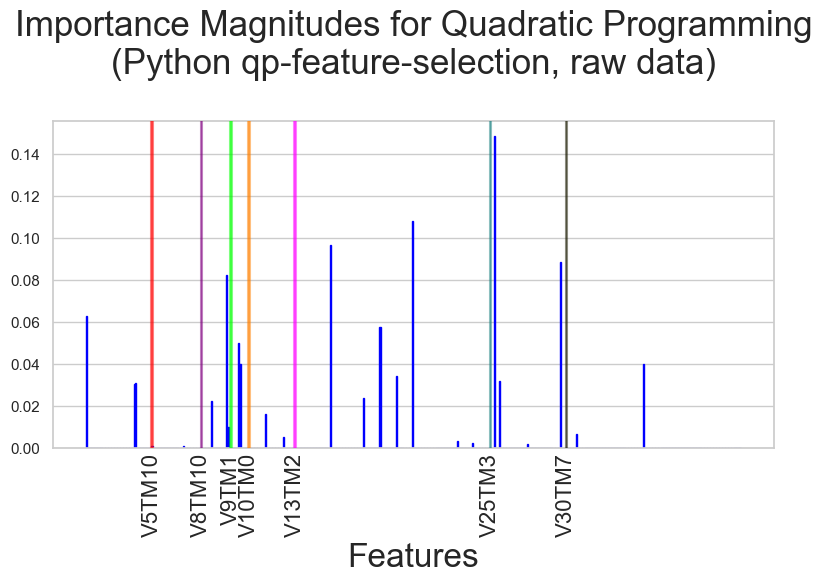

In [39]:
from pathlib import Path
from qp_feature_selection import (
    create_opt_problem,
    solve_opt_problem,
    normalize_design_and_target,
    split_train_test,
)

# Use the continuous raw dataset (not the rectified/binarized +/-1 dataset).
qp_feature_cols = [c for c in dset.columns if c not in EXCLUDE_COLS and c != RESP_COL]
X_qp_raw = dset[qp_feature_cols].to_numpy(dtype=float)
y_qp_raw = dset[RESP_COL].astype(float).to_numpy()

# Match MATLAB QPFeatureSelection main.m defaults: normalize then 70/30 chronological split.
X_qp_raw, y_qp_raw = normalize_design_and_target(X_qp_raw, y_qp_raw)
X_qp_train, y_qp_train, _, _ = split_train_test(X_qp_raw, y_qp_raw, test_set_ratio=0.7)

Q_qp_raw, b_qp_raw = create_opt_problem(X_qp_train, y_qp_train, sim="correl", rel="correl")
qp_weights_raw = solve_opt_problem(Q_qp_raw, b_qp_raw)

# Optional numeric comparison to MATLAB-exported weights used in the previous plot cell.
if Path("x_out.csv").exists():
    matlab_weights = pd.read_csv("x_out.csv", header=None).iloc[:, 0].to_numpy(dtype=float)
    ncmp = min(len(matlab_weights), len(qp_weights_raw))
    corr = float(np.corrcoef(matlab_weights[:ncmp], qp_weights_raw[:ncmp])[0, 1])
    mae = float(np.mean(np.abs(matlab_weights[:ncmp] - qp_weights_raw[:ncmp])))
    print(f"MATLAB vs Python QP weights on first {ncmp} features -> corr={corr:.6f}, MAE={mae:.6e}")

TRANS = 0.5
BARHT = 1.05
n = len(qp_feature_cols)
markers = np.zeros(n, dtype=float)
cols = np.zeros((n, 4), dtype=float)

# Build marker feature set from the Case 1 constants instead of hardcoded names.
marker_from_disp = [f"V{r}TM{CASE1_DISP[r - 1]}" for r in CASE1_RELEVANT]
marker_features = list(dict.fromkeys(list(TRUE_FEATURES) + marker_from_disp))

palette = [
    (1.0, 0.0, 0.0, TRANS),
    (0.5, 0.0, 0.5, TRANS),
    (0.0, 1.0, 0.0, TRANS),
    (1.0, 0.5, 0.0, TRANS),
    (1.0, 0.0, 1.0, TRANS),
    (0.1, 0.5, 0.5, TRANS),
    (0.1, 0.1, 0.0, TRANS),
]

feature_to_color = {f: palette[i % len(palette)] for i, f in enumerate(marker_features)}
marker_height = float(qp_weights_raw.max()) * BARHT
for i, name in enumerate(qp_feature_cols):
    if name in feature_to_color:
        markers[i] = marker_height
        cols[i, :] = feature_to_color[name]

x = np.arange(n)
width = 0.85
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, qp_weights_raw, width=width, edgecolor="blue", color="blue", zorder=2)
idx = markers > 0
ax.bar(x[idx], markers[idx], width=width, edgecolor=cols[idx], color=cols[idx], linewidth=1.5, zorder=3)
ax.set_ylim(0, float(qp_weights_raw.max()) * 1.05)
ax.set_title("Importance Magnitudes for Quadratic Programming\n(Python qp-feature-selection, raw data)\n", fontsize=ax.title.get_fontsize() * 2.1)

labels = [""] * n
marker_set = set(marker_features)
for i, name in enumerate(qp_feature_cols):
    if name in marker_set:
        labels[i] = name

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=16)
ax.set_xlabel("Features", fontsize=ax.xaxis.label.get_fontsize() * 2)
ax.tick_params(axis="x", length=0)
ax.grid(False, axis="x")
ax.set_facecolor("white")
output_dir = Path("Figures") 
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "katrutsa_figure.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()
